   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  

===== LINEAR REGRESSION RESULTS =====
MAE: 244419.99901363705
MSE: 78729422262.64821
RMSE: 280587.637401665
R2 Score: -0.011961539273188437


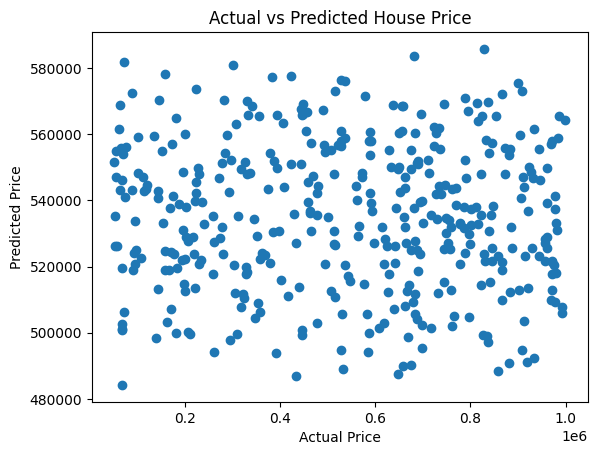


===== LOGISTIC REGRESSION RESULTS =====
Accuracy: 0.4475
Confusion Matrix:
 [[105  85]
 [136  74]]
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.55      0.49       190
           1       0.47      0.35      0.40       210

    accuracy                           0.45       400
   macro avg       0.45      0.45      0.44       400
weighted avg       0.45      0.45      0.44       400



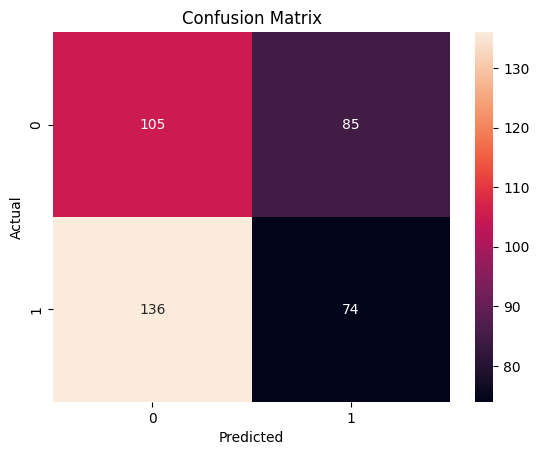


===== HYPERPARAMETER TUNING =====
Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Best Cross Validation Accuracy: 0.5149999999999999


In [ ]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ==============================
# STEP 2: Load Dataset
# ==============================
data = pd.read_csv("House Price Prediction Dataset.csv")
print(data.head())

# ==============================
# STEP 3: Data Cleaning
# ==============================
data = data.dropna()

# ==============================
# STEP 4: Encode Categorical Columns
# ==============================
le = LabelEncoder()

data["Location"] = le.fit_transform(data["Location"])
data["Condition"] = le.fit_transform(data["Condition"])
data["Garage"] = le.fit_transform(data["Garage"])

# ==============================
# PART A: LINEAR REGRESSION
# ==============================
X = data.drop(columns=["Price", "Id"])
y = data["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("\n===== LINEAR REGRESSION RESULTS =====")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

# ==============================
# PART B: LOGISTIC REGRESSION
# ==============================
# Create binary target (Expensive / Not Expensive)
data["Expensive"] = data["Price"].apply(lambda x: 1 if x >= data["Price"].median() else 0)

X = data.drop(columns=["Price", "Expensive", "Id"])
y = data["Expensive"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==============================
# PART C: HYPERPARAMETER TUNING
# ==============================
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("\n===== HYPERPARAMETER TUNING =====")
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)